# SF$_6$-like - calculate observational network global- annual-mean, latitudinal gradient and seasonality

Calculate global-mean, latitudinal gradient and seasonality
based on the observational network.
We also perform an EOF analysis for the latitudinal gradient.
We also perform an EOF analysis for the seasonality change.

## Imports

In [1]:
from pathlib import Path

import cf_xarray.units
import matplotlib.axes
import matplotlib.pyplot as plt
import pint_xarray
import xarray as xr
from pydoit_nb.config_handling import get_config_for_step_id

import local.binned_data_interpolation
import local.binning
import local.latitudinal_gradient
import local.mean_preserving_interpolation
import local.raw_data_processing
import local.seasonality
import local.xarray_space
import local.xarray_time
from local.config import load_config_from_file

In [2]:
cf_xarray.units.units.define("ppm = 1 / 1000000")
cf_xarray.units.units.define("ppb = ppm / 1000")
cf_xarray.units.units.define("ppt = ppb / 1000")

pint_xarray.accessors.default_registry = pint_xarray.setup_registry(cf_xarray.units.units)

## Define branch this notebook belongs to

In [3]:
step: str = "calculate_sf6_like_monthly_fifteen_degree_pieces"

## Parameters

In [4]:
config_file: str = "../../dev-config-absolute.yaml"  # config file
step_config_id: str = "ch2cl2"  # config ID to select for this branch

In [5]:
# Parameters
config_file = "/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/output-bundles/v1.0.0/v1.0.0-config.yaml"
step_config_id = "cfc114"


## Load config

In [6]:
config = load_config_from_file(Path(config_file))
config_step = get_config_for_step_id(config=config, step=step, step_config_id=step_config_id)

## Action

### Load data

In [7]:
interpolated_spatial: xr.DataArray = xr.load_dataarray(  # type: ignore
    config_step.observational_network_interpolated_file
).pint.quantify()
interpolated_spatial

Magnitude,[[[16.491 16.491 16.491 ... 16.572 16.572 16.572] [16.491 16.491 16.491 ... 16.572 16.572 16.572] [16.491 16.491 16.491 ... 16.572 16.572 16.572] [16.491 16.491 16.491 ... 16.572 16.572 16.572] [16.491 16.491 16.491 ... 16.572 16.572 16.572] [16.491 16.491 16.491 ... 16.572 16.572 16.572]] [[16.498 16.498 16.498 ... 16.635 16.635 16.635] [16.498 16.498 16.498 ... 16.635 16.635 16.635] [16.498 16.498 16.498 ... 16.635 16.635 16.635] [16.498 16.498 16.498 ... 16.635 16.635 16.635] [16.498 16.498 16.498 ... 16.635 16.635 16.635] [16.498 16.498 16.498 ... 16.635 16.635 16.635]] [[16.497 16.497 16.497 ... 16.593 16.593 16.593] [16.497 16.497 16.497 ... 16.593 16.593 16.593] [16.497 16.497 16.497 ... 16.593 16.593 16.593] [16.497 16.497 16.497 ... 16.593 16.593 16.593] [16.497 16.497 16.497 ... 16.593 16.593 16.593] [16.497 16.497 16.497 ... 16.593 16.593 16.593]] ... [[16.253 16.253 16.253 ... 16.296 16.293 16.29] [16.253 16.253 16.253 ... 16.296 16.293 16.29] [16.253 16.253 16.253 ... 16.263 16.293 16.29] [16.253 16.253 16.253 ... 16.279 16.2845 16.29] [16.253 16.253 16.253 ... 16.287499999999998 16.293 16.29] [16.253 16.253 16.253 ... 16.296 16.293 16.29]] [[16.253 16.253 16.253 ... 16.288333333333334 16.291666666666668 16.295] [16.253 16.253 16.253 ... 16.28833333333333 16.291666666666668 16.295] [16.253 16.253 16.253 ... 16.267 16.291666666666664 16.295] [16.253 16.253 16.253 ... 16.286 16.2905 16.295] [16.253 16.253 16.253 ... 16.287166666666668 16.291666666666668 16.295] [16.253 16.253 16.253 ... 16.288333333333334 16.291666666666668 16.295]] [[16.247 16.247 16.247 ... 16.293666666666667 16.295333333333335 16.297] [16.247 16.247 16.247 ... 16.293666666666667 16.295333333333335 16.297] [16.247 16.247 16.247 ... 16.259 16.295333333333332 16.297] [16.247 16.247 16.247 ... 16.287 16.292 16.297] [16.247 16.247 16.247 ... 16.2635 16.295333333333335 16.297] [16.247 16.247 16.247 ... 16.293666666666667 16.295333333333335 16.297]]]
Units,ppt


In [8]:
if config_step.year_drop_observational_data_before_and_including is not None:
    interpolated_spatial = interpolated_spatial.sel(
        time=interpolated_spatial["time"].dt.year
        > config_step.year_drop_observational_data_before_and_including
    )

if config_step.year_drop_observational_data_after_and_including is not None:
    interpolated_spatial = interpolated_spatial.sel(
        time=interpolated_spatial["time"].dt.year
        < config_step.year_drop_observational_data_after_and_including
    )

interpolated_spatial

Magnitude,[[[16.491 16.491 16.491 ... 16.572 16.572 16.572] [16.491 16.491 16.491 ... 16.572 16.572 16.572] [16.491 16.491 16.491 ... 16.572 16.572 16.572] [16.491 16.491 16.491 ... 16.572 16.572 16.572] [16.491 16.491 16.491 ... 16.572 16.572 16.572] [16.491 16.491 16.491 ... 16.572 16.572 16.572]] [[16.498 16.498 16.498 ... 16.635 16.635 16.635] [16.498 16.498 16.498 ... 16.635 16.635 16.635] [16.498 16.498 16.498 ... 16.635 16.635 16.635] [16.498 16.498 16.498 ... 16.635 16.635 16.635] [16.498 16.498 16.498 ... 16.635 16.635 16.635] [16.498 16.498 16.498 ... 16.635 16.635 16.635]] [[16.497 16.497 16.497 ... 16.593 16.593 16.593] [16.497 16.497 16.497 ... 16.593 16.593 16.593] [16.497 16.497 16.497 ... 16.593 16.593 16.593] [16.497 16.497 16.497 ... 16.593 16.593 16.593] [16.497 16.497 16.497 ... 16.593 16.593 16.593] [16.497 16.497 16.497 ... 16.593 16.593 16.593]] ... [[16.253 16.253 16.253 ... 16.296 16.293 16.29] [16.253 16.253 16.253 ... 16.296 16.293 16.29] [16.253 16.253 16.253 ... 16.263 16.293 16.29] [16.253 16.253 16.253 ... 16.279 16.2845 16.29] [16.253 16.253 16.253 ... 16.287499999999998 16.293 16.29] [16.253 16.253 16.253 ... 16.296 16.293 16.29]] [[16.253 16.253 16.253 ... 16.288333333333334 16.291666666666668 16.295] [16.253 16.253 16.253 ... 16.28833333333333 16.291666666666668 16.295] [16.253 16.253 16.253 ... 16.267 16.291666666666664 16.295] [16.253 16.253 16.253 ... 16.286 16.2905 16.295] [16.253 16.253 16.253 ... 16.287166666666668 16.291666666666668 16.295] [16.253 16.253 16.253 ... 16.288333333333334 16.291666666666668 16.295]] [[16.247 16.247 16.247 ... 16.293666666666667 16.295333333333335 16.297] [16.247 16.247 16.247 ... 16.293666666666667 16.295333333333335 16.297] [16.247 16.247 16.247 ... 16.259 16.295333333333332 16.297] [16.247 16.247 16.247 ... 16.287 16.292 16.297] [16.247 16.247 16.247 ... 16.2635 16.295333333333335 16.297] [16.247 16.247 16.247 ... 16.293666666666667 16.295333333333335 16.297]]]
Units,ppt


### Drop out any years that have nan

These break everything later on

In [9]:
interpolated_spatial_no_year_with_nan = local.xarray_time.convert_time_to_year_month(
    interpolated_spatial
).dropna("year")
if interpolated_spatial_no_year_with_nan["year"].shape[0] != (
    interpolated_spatial_no_year_with_nan["year"].max()
    - interpolated_spatial_no_year_with_nan["year"].min()
    + 1
):
    msg = f"Missing years, this will not end well {interpolated_spatial_no_year_with_nan['year'].values=}"
    raise AssertionError(msg)

interpolated_spatial_no_year_with_nan

<xarray.DataArray 'cfc114' (lon: 6, lat: 12, year: 11, month: 12)> Size: 76kB
<Quantity([[[[16.492      16.486      16.466      ... 16.504      16.479
    16.47      ]
   [16.46       16.421      16.41       ... 16.422      16.405
    16.411     ]
   [16.401      16.411      16.39       ... 16.405      16.416
    16.415     ]
   ...
   [16.276      16.255      16.259      ... 16.263      16.261
    16.254     ]
   [16.254      16.248      16.238      ... 16.232      16.231
    16.251     ]
   [16.247      16.259      16.246      ... 16.253      16.253
    16.247     ]]

  [[16.492      16.486      16.466      ... 16.504      16.479
    16.47      ]
   [16.46       16.421      16.41       ... 16.422      16.405
    16.411     ]
   [16.401      16.411      16.39       ... 16.405      16.416
    16.415     ]
...
   [16.308      16.295      16.3        ... 16.289      16.29
    16.33      ]
   [16.489      16.35       16.326      ... 16.29266667 16.28233333
    16.293     ]
   [16.28333333 16.29366667 16.29933333 ... 16.293      16.29166667
    16.29533333]]

  [[16.523      16.528      16.531      ... 16.357      16.536
    16.523     ]
   [16.422      16.378      16.383      ... 16.502      16.487
    16.452     ]
   [16.449      16.434      16.432      ... 16.412      16.42
    16.425     ]
   ...
   [16.308      16.295      16.3        ... 16.289      16.29
    16.33      ]
   [16.489      16.35       16.326      ... 16.291      16.286
    16.299     ]
   [16.287      16.291      16.294      ... 16.29       16.295
    16.297     ]]]], 'ppt')>
Coordinates:
  * year     (year) int64 88B 2007 2008 2009 2010 2011 ... 2014 2015 2016 2017
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat      (lat) float64 96B -82.5 -67.5 -52.5 -37.5 ... 37.5 52.5 67.5 82.5
  * lon      (lon) float64 48B -150.0 -90.0 -30.0 30.0 90.0 150.0
Attributes:
    description:  Interpolated spatial data

In [10]:
interpolated_spatial_nan_free = local.xarray_time.convert_year_month_to_time(
    interpolated_spatial_no_year_with_nan
)
interpolated_spatial_nan_free

Magnitude,[[[16.492 16.486 16.466 ... 16.253 16.253 16.247] [16.492 16.486 16.466 ... 16.253 16.253 16.247] [16.492 16.486 16.466 ... 16.253 16.253 16.247] ... [16.523 16.528 16.531 ... 16.296 16.288333333333334 16.293666666666667] [16.523 16.528 16.531 ... 16.293 16.291666666666668 16.295333333333335] [16.523 16.528 16.531 ... 16.29 16.295 16.297]] [[16.492 16.486 16.466 ... 16.253 16.253 16.247] [16.492 16.486 16.466 ... 16.253 16.253 16.247] [16.492 16.486 16.466 ... 16.253 16.253 16.247] ... [16.523 16.528 16.531 ... 16.296 16.28833333333333 16.293666666666667] [16.523 16.528 16.531 ... 16.293 16.291666666666668 16.295333333333335] [16.523 16.528 16.531 ... 16.29 16.295 16.297]] [[16.492 16.486 16.466 ... 16.253 16.253 16.247] [16.492 16.486 16.466 ... 16.253 16.253 16.247] [16.492 16.486 16.466 ... 16.253 16.253 16.247] ... [16.523 16.528 16.531 ... 16.263 16.267 16.259] [16.523 16.528 16.531 ... 16.293 16.291666666666664 16.295333333333332] [16.523 16.528 16.531 ... 16.29 16.295 16.297]] [[16.492 16.486 16.466 ... 16.253 16.253 16.247] [16.492 16.486 16.466 ... 16.253 16.253 16.247] [16.492 16.486 16.466 ... 16.253 16.253 16.247] ... [16.523 16.528 16.531 ... 16.279 16.286 16.287] [16.523 16.528 16.531 ... 16.2845 16.2905 16.292] [16.523 16.528 16.531 ... 16.29 16.295 16.297]] [[16.492 16.486 16.466 ... 16.253 16.253 16.247] [16.492 16.486 16.466 ... 16.253 16.253 16.247] [16.492 16.486 16.466 ... 16.253 16.253 16.247] ... [16.523 16.528 16.531 ... 16.287499999999998 16.287166666666668 16.2635] [16.523 16.528 16.531 ... 16.293 16.291666666666668 16.295333333333335] [16.523 16.528 16.531 ... 16.29 16.295 16.297]] [[16.492 16.486 16.466 ... 16.253 16.253 16.247] [16.492 16.486 16.466 ... 16.253 16.253 16.247] [16.492 16.486 16.466 ... 16.253 16.253 16.247] ... [16.523 16.528 16.531 ... 16.296 16.288333333333334 16.293666666666667] [16.523 16.528 16.531 ... 16.293 16.291666666666668 16.295333333333335] [16.523 16.528 16.531 ... 16.29 16.295 16.297]]]
Units,ppt


### Longitudinal-mean

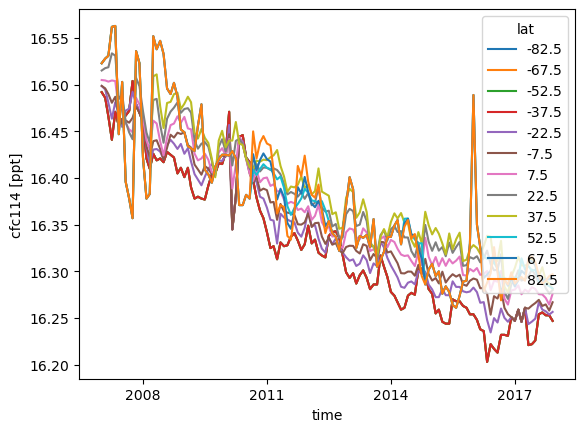

In [11]:
lon_mean = interpolated_spatial_nan_free.mean(dim="lon")
lon_mean.plot(hue="lat")  # type: ignore

### Global-, annual-mean

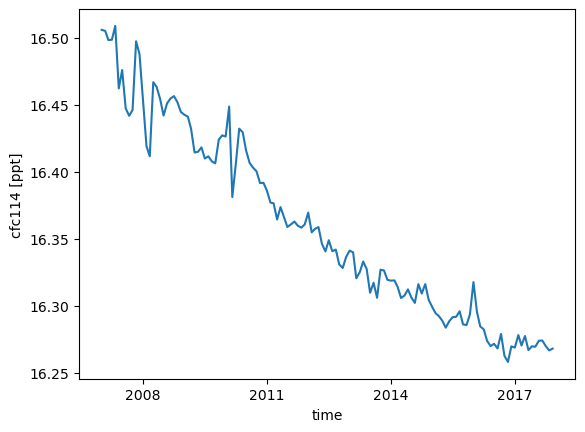

In [12]:
global_mean = local.xarray_space.calculate_global_mean_from_lon_mean(lon_mean)
global_mean.plot()  # type: ignore

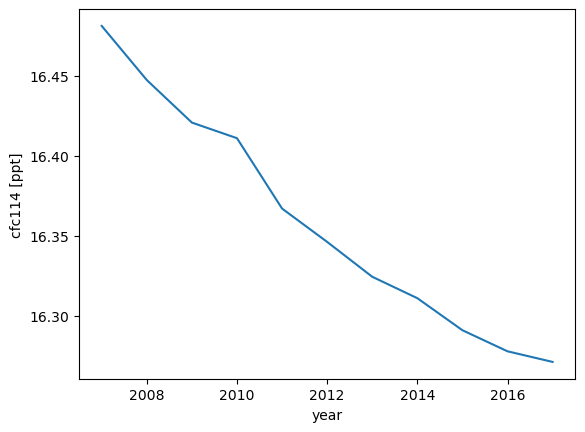

In [13]:
global_annual_mean = global_mean.groupby("time.year").mean()
global_annual_mean.plot()  # type: ignore

### Latitudinal gradient

In [14]:
(
    lat_residuals_annual_mean,
    lat_gradient_full_eofs_pcs,
) = local.latitudinal_gradient.calculate_eofs_pcs(lon_mean, global_mean)
lat_gradient_full_eofs_pcs

Magnitude,[[-0.371212681602518 -0.1048837863169295 0.22647131417255564 0.015952833438953217 0.0293832444698813 -0.06737182001891354 -0.04121343277236842 -0.05202341052252931 0.202889470063924 -0.8451674335670011 -0.06356427258086936] [-0.3712126816025178 -0.10488378631692971 0.2264713141725558 0.015952833438953703 0.02938324446988098 -0.06737182001891155 -0.04121343277237076 -0.05202341052253144 0.19802483839610724 0.19387292259803354 -0.5013936092235584] [-0.3712126816025178 -0.10488378631692999 0.2264713141725557 0.01595283343895348 0.029383244469880828 -0.06737182001891166 -0.04121343277236936 -0.052023410522532676 0.19858496754735266 0.1964102223809027 0.8233187163012873] [-0.3712126816025178 -0.10488378631692995 0.22647131417255567 0.015952833438953647 0.029383244469880884 -0.06737182001891108 -0.041213432772369926 -0.05202341052253194 0.1989881130789555 0.4577309688832192 -0.2582834012553277] [-0.17841447262547042 0.01368328007274192 -0.24422011598668888 -0.15831209468652685 -0.16655194008753824 0.541961911950768 0.3441739529589076 0.5431450591600067 0.3851599019465892 0.001373130143746099 3.735084626728937e-05] [-0.062188873579742565 0.08010918857937209 -0.5423497417955331 0.26679333033586766 -0.14072733637261542 0.06945457483180971 0.08684328215141285 -0.6491387661886654 0.41332748713986156 0.0014735501514076773 4.008239526451354e-05] [0.10590888648106128 0.17207371860874623 -0.23755446203078343 0.01011882280658409 -0.22778384246144318 -0.595289845728649 -0.3973756031312886 0.4094318710924127 0.41332748713885087 0.0014735501514073783 4.008239526563583e-05] [0.2707629671195003 0.23740451364985046 0.1770284680372141 -0.7384290068724484 0.2697127011133453 0.04610078796302443 -0.04269830485812959 -0.262042621205039 0.3851599019473156 0.0013731301437476422 3.735084626667768e-05] [0.3771905970286475 0.3649846775235732 0.5396727048202229 0.5273651813941227 -0.04887573603283062 0.12881371844241143 0.16063153485737308 0.03122610599919996 0.33074430594346943 0.0011791335859930936 3.2073898821203503e-05] [0.260201917260327 -0.5294747355439579 -0.10147806322675194 0.22945848256536341 0.5345089945187165 0.25304969222437274 -0.40409172921893305 0.10755703901696483 0.2537890320705796 0.000904781022963493 2.4611168175869595e-05] [0.24235780798247838 -0.494368436744544 0.014470624944897335 -0.03642988240848854 0.05863458091271852 -0.45627009253715883 0.6766687281695547 0.019290783245762454 0.15953845506845885 0.0005687691284438708 1.547122708925989e-05] [0.2446651428149629 -0.4532826070236593 0.2270049391372977 -0.15896060241256157 -0.7299627599589663 0.19491715748704408 -0.2459769253165435 -0.1535254145771952 0.0544155960037965 0.00019399655775301962 5.276947445916858e-06]]
Units,ppt
Magnitude,[[0.025137719799349943 0.0003136660486203869 0.001952064807212627 -0.008732998454702438 0.002757289905266355 0.0006736564282324856 -0.0002659199310888126 0.0003788103716545036 -4.677567114523896e-16 1.1686205962480028e-18 -1.8228990513442884e-19] [0.0770117965137659 -0.030552377343376447 0.00040656383471340476 -0.005677519946807 -0.0007650097979517301 -0.00030874549512560916 0.00023294280119479452 -0.0006260321758183374 4.289943498614641e-16 -1.5070204614918885e-18 1.9108692312179018e-19] [0.06200151187542952 0.015248906869666774 -0.001924738667496832 -0.0007875764843697566 -9.256787468447582e-05 0.001306341090633471 0.0013998273059930132 0.0005157410238874778 9.427321530586199e-16 -5.495215274815593e-19 7.637567199352906e-20] [0.018774535588140476 0.017745395903477346 0.009579592985671044 -0.0022765646539271646 -0.0037813078895487244 -2.8178459414855917e-05 -0.00019747307894176012 0.00021041487062008516 -5.08509669994375e-16 -1.3918508456739924e-18 -4.1680222580570183e-19] [0.09634754285820864 0.008241845663461719 -0.0029205113097601 0.00016141853036102659 -0.001817505168972102 0.0012602960120860396 -0.0007587641807756645 -0.00029768912547098583 1.1934088968534222e-15 1.7322072199844589e-18 -2.488262721980733e-19] [0.054972670950869794 0.002648

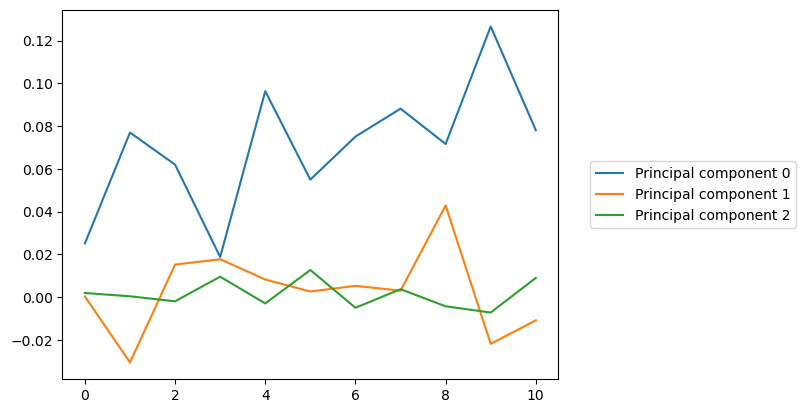

In [15]:
fig, ax = plt.subplots()
n_eofs_to_show = 3

for i in range(n_eofs_to_show):
    ax.plot(
        lat_gradient_full_eofs_pcs["principal-components"].sel(eof=i).data.m,
        label=f"Principal component {i}",
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

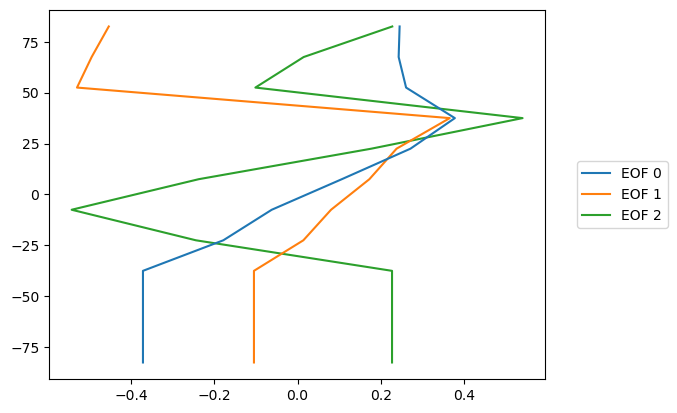

In [16]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        lat_gradient_full_eofs_pcs["eofs"].sel(eof=i).data.m,
        lat_gradient_full_eofs_pcs["lat"].data,
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

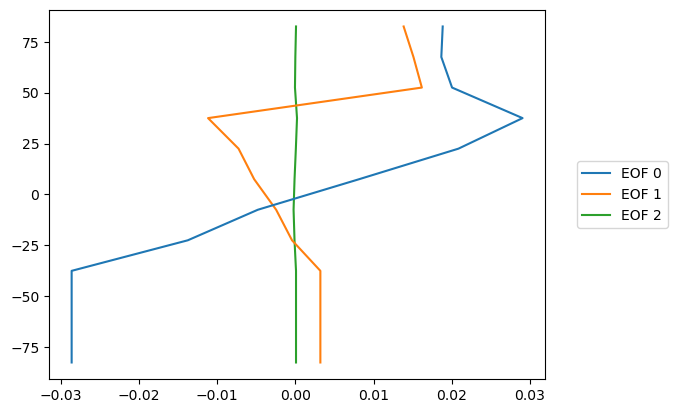

In [17]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        lat_gradient_full_eofs_pcs["principal-components"].sel(eof=i).isel(year=1)
        @ lat_gradient_full_eofs_pcs["eofs"].sel(eof=i),
        lat_gradient_full_eofs_pcs["lat"],
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

In [18]:
lat_gradient_eofs_pcs = lat_gradient_full_eofs_pcs.sel(eof=range(config_step.lat_gradient_n_eofs_to_use))
lat_gradient_eofs_pcs

Magnitude,[[-0.371212681602518] [-0.3712126816025178] [-0.3712126816025178] [-0.3712126816025178] [-0.17841447262547042] [-0.062188873579742565] [0.10590888648106128] [0.2707629671195003] [0.3771905970286475] [0.260201917260327] [0.24235780798247838] [0.2446651428149629]]
Units,ppt
Magnitude,[[0.025137719799349943] [0.0770117965137659] [0.06200151187542952] [0.018774535588140476] [0.09634754285820864] [0.054972670950869794] [0.07511256776734553] [0.08818610715069133] [0.07166244932211313] [0.12663199282406637] [0.07812629731114558]]
Units,dimensionless


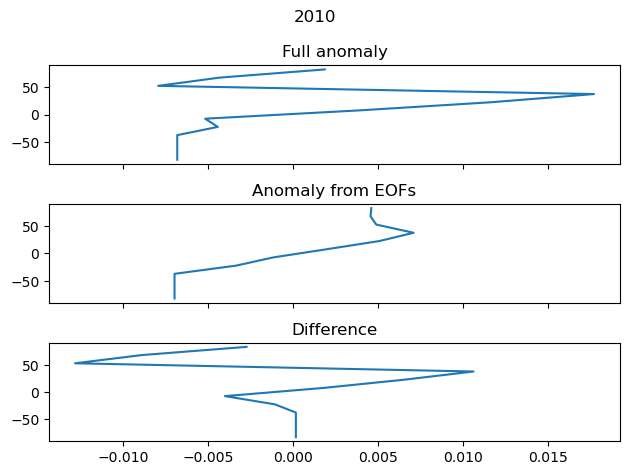

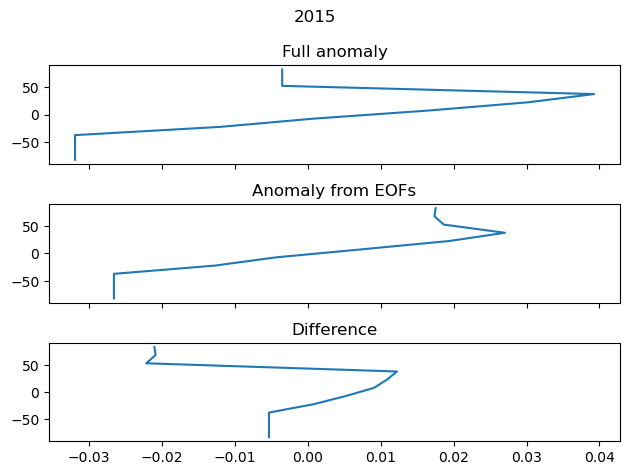

In [19]:
latitudinal_anomaly_from_eofs = lat_gradient_eofs_pcs["principal-components"] @ lat_gradient_eofs_pcs["eofs"]

for year in latitudinal_anomaly_from_eofs["year"]:
    if year % 5:
        continue

    fig, axes = plt.subplots(nrows=3, sharex=True, sharey=True)
    if isinstance(axes, matplotlib.axes.Axes):
        raise TypeError(type(axes))

    selected = lat_residuals_annual_mean.sel(year=year)
    axes[0].plot(selected.data.m, lat_residuals_annual_mean.lat)
    axes[0].set_title("Full anomaly")

    selected_eofs = latitudinal_anomaly_from_eofs.sel(year=year)
    axes[1].plot(selected_eofs.data.m, latitudinal_anomaly_from_eofs.lat)
    axes[1].set_title("Anomaly from EOFs")

    axes[2].plot(selected.data.m - selected_eofs.data.m, lat_residuals_annual_mean.lat)
    axes[2].set_title("Difference")

    axes[0].set_ylim([-90, 90])

    plt.suptitle(str(int(year)))
    plt.tight_layout()
    plt.show()

### Seasonality

In [20]:
(
    seasonality,
    relative_seasonality,
    lon_mean_ym_monthly_anomalies,
) = local.seasonality.calculate_seasonality(
    lon_mean=lon_mean,
    global_mean=global_mean,
)

/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore
/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/.pixi/envs/all-dev/lib/python3.11/importlib/__init__.py:126: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  return _bootstrap._gcd_import(name[level:], package, level)


Calculating output values:   0%|                                                                                                                                                                                      | 0/132 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 132/132 [00:00<00:00, 16757.41it/s]


/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/132 [00:00<?, ?it/s]

...

Calculating output values:   0%|                                                                                                                                                                                      | 0/132 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 132/132 [00:00<00:00, 19286.84it/s]


/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/132 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 132/132 [00:00<00:00, 19183.26it/s]

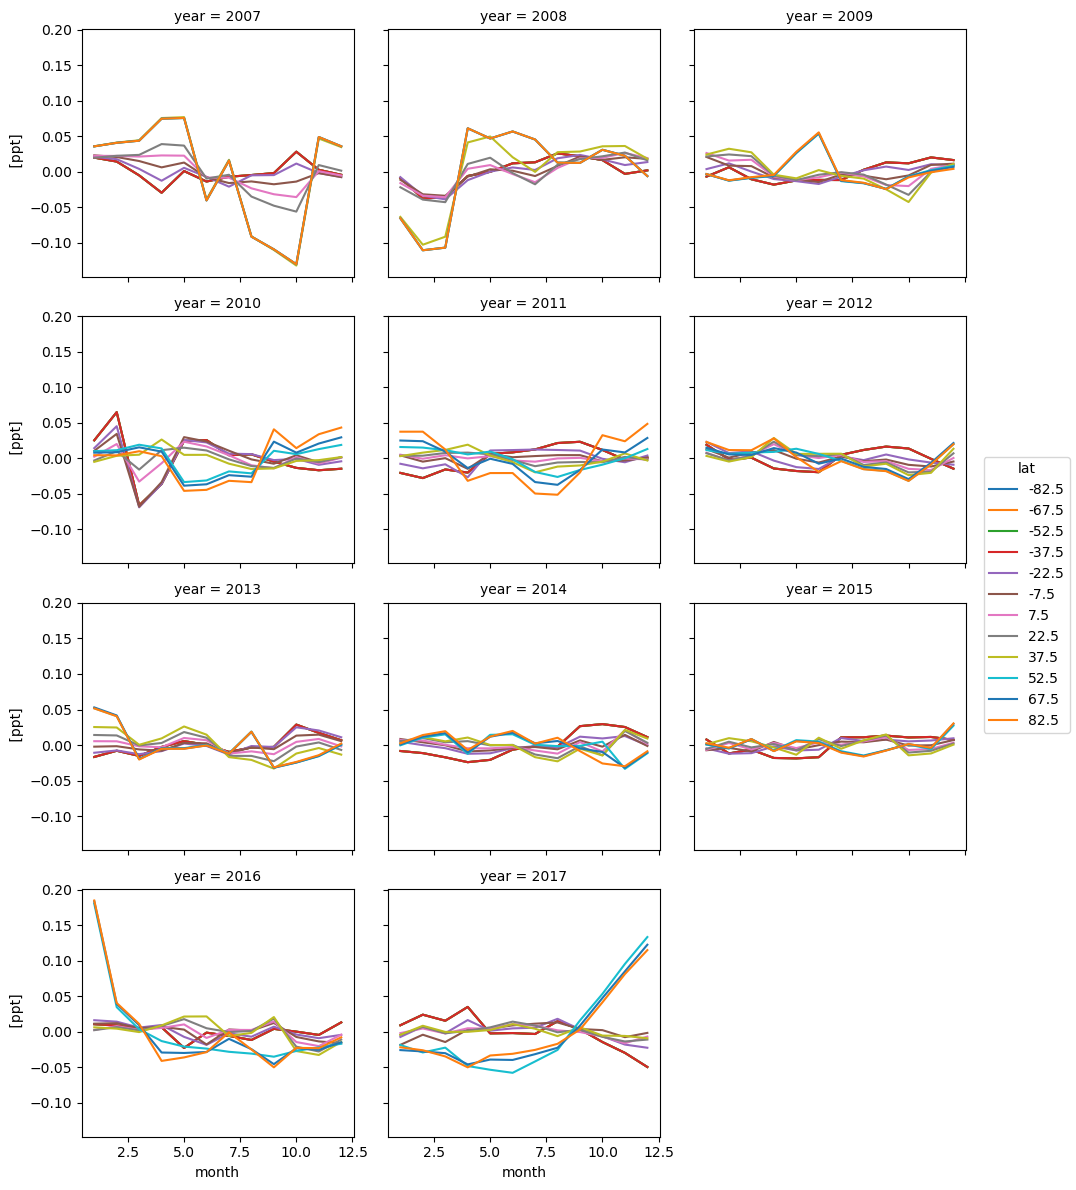

In [21]:
lon_mean_ym_monthly_anomalies.plot.line(hue="lat", col="year", col_wrap=3)

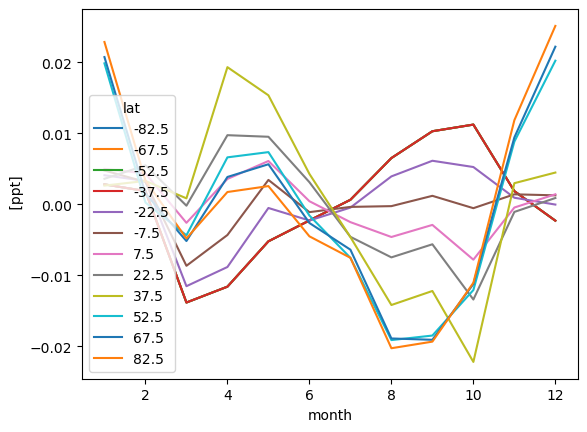

In [22]:
seasonality.plot.line(hue="lat")

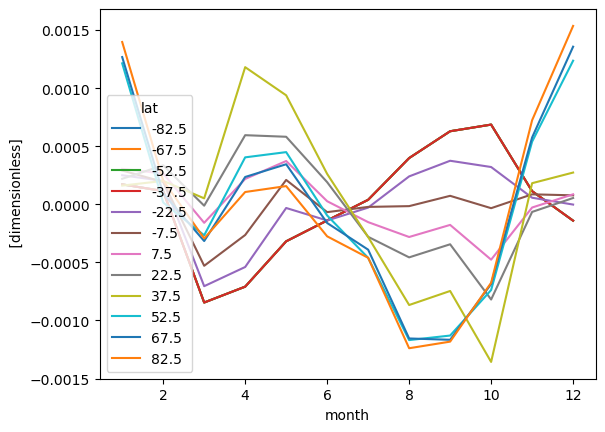

In [23]:
relative_seasonality.plot.line(hue="lat")

### Save

In [24]:
config_step.observational_network_global_annual_mean_file.parent.mkdir(exist_ok=True, parents=True)
global_annual_mean.pint.dequantify().to_netcdf(config_step.observational_network_global_annual_mean_file)
global_annual_mean

Magnitude,[16.48128468311699 16.447443847067174 16.42082215889856 16.41105938127337 16.36704692390241 16.346191094507024 16.324379986376957 16.310986537330006 16.290938050723625 16.277759717679395 16.271119152347577]
Units,ppt


In [25]:
config_step.observational_network_latitudinal_gradient_eofs_file.parent.mkdir(exist_ok=True, parents=True)
lat_gradient_eofs_pcs.pint.dequantify().to_netcdf(
    config_step.observational_network_latitudinal_gradient_eofs_file
)
lat_gradient_eofs_pcs

Magnitude,[[-0.371212681602518] [-0.3712126816025178] [-0.3712126816025178] [-0.3712126816025178] [-0.17841447262547042] [-0.062188873579742565] [0.10590888648106128] [0.2707629671195003] [0.3771905970286475] [0.260201917260327] [0.24235780798247838] [0.2446651428149629]]
Units,ppt
Magnitude,[[0.025137719799349943] [0.0770117965137659] [0.06200151187542952] [0.018774535588140476] [0.09634754285820864] [0.054972670950869794] [0.07511256776734553] [0.08818610715069133] [0.07166244932211313] [0.12663199282406637] [0.07812629731114558]]
Units,dimensionless


In [26]:
# Use relative seasonality
config_step.observational_network_seasonality_file.parent.mkdir(exist_ok=True, parents=True)
relative_seasonality.pint.dequantify().to_netcdf(config_step.observational_network_seasonality_file)
relative_seasonality

Magnitude,[[0.00017194665499650275 0.00011397270887712298 -0.0008453043310463781 -0.0007087111918498278 -0.0003183991664849331 -0.00013900317418986466 3.9070025781270047e-05 0.00039819542134677605 0.0006290994745556149 0.0006863925574471959 0.00011336856765244624 -0.00014063601354152532] [0.00017194665499650275 0.00011397270887712298 -0.0008453043310463781 -0.0007087111918498278 -0.0003183991664849331 -0.00013900317418986466 3.9070025781270047e-05 0.00039819542134677605 0.0006290994745556149 0.0006863925574471959 0.00011336856765244624 -0.00014063601354152532] [0.00017194665499650275 0.00011397270887712298 -0.0008453043310463781 -0.0007087111918498278 -0.0003183991664849331 -0.00013900317418986466 3.9070025781270047e-05 0.00039819542134677605 0.0006290994745556149 0.0006863925574471959 0.00011336856765244624 -0.00014063601354152532] [0.00017194665499650275 0.00011397270887712298 -0.0008453043310463781 -0.0007087111918498278 -0.0003183991664849331 -0.00013900317418986466 3.9070025781270047e-05 0.00039819542134677605 0.0006290994745556149 0.0006863925574471959 0.00011336856765244624 -0.00014063601354152532] [0.00025026003533699974 0.00020142887415316128 -0.0007046218422406169 -0.0005395104786125354 -3.14817644306931e-05 -0.00013915301587464235 -2.825788202411087e-05 0.00024046608992044901 0.00037507792152202733 0.0003211315920796675 5.670890085748095e-05 -2.0528204525798365e-06] [0.00029112325326481473 0.00019330408240012025 -0.000529070290218579 -0.0002640673831184437 0.0002100304677104755 -6.723747987361947e-05 -2.216385850854872e-05 -1.553948319119267e-05 7.321306707940455e-05 -3.3146942837764436e-05 8.616844451991582e-05 7.738447710290646e-05] [0.0003049002406893587 0.00026524211800622914 -0.0001591085682454101 0.000218448788377066 0.0003728632402070304 2.673086504242906e-05 -0.00015327425330973732 -0.0002811769398098228 -0.00017715958826989154 -0.0004764175387263474 -2.74971601027754e-05 8.644757430363746e-05] [0.00021986619150869308 0.0003352187227949068 -1.177054489904073e-05 0.0005951916320223263 0.0005816221621344638 0.000190591318601685 -0.00027973531978801495 -0.0004566280364222352 -0.0003439169404483212 -0.0008194496113243849 -6.541174376535649e-05 5.442176126810854e-05] [0.00016118274871910568 0.000201552935204174 5.152731407950106e-05 0.0011807698902834844 0.000938455487808449 0.00026190215744881137 -0.00028175327681283793 -0.0008666749837400659 -0.0007459351544396595 -0.0013565906637891885 0.0001820598031296235 0.00027350531183286075] [0.0012136288581607686 1.561808022698453e-05 -0.00026653760514771884 0.0004044052010969453 0.0004494128094088938 -9.61237575182125e-05 -0.0004606385338951256 -0.001168575412818629 -0.0011295927856688058 -0.0007377366545222469 0.0005397024361073341 0.0012364612968623451] [0.001267699087445065 9.305585168792203e-05 -0.0003160390456811477 0.00023544233255398772 0.0003450320836502873 -0.0001607103875729498 -0.0003902512333240262 -0.0011546330672233959 -0.0011660678695175732 -0.0006861277506498376 0.0005756172443816755 0.0013570030373892493] [0.001397316140749772 0.00020501192288206746 -0.00029342562398692993 0.00010601959317147116 0.0001569879820123574 -0.00027548923965354166 -0.00046022838545532686 -0.0012387649568850329 -0.0011819261233745487 -0.0006752988688558512 0.0007240468178975775 0.0015357695198709572]]
Units,dimensionless
